<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part2_TF_Custom_Objects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔧 Part 2 · TensorFlow Custom Deep Learning Objects
**Topics:**  
Custom Activation · Custom Initializer · Custom Regularizer · Custom Constraint  
Custom Loss · Custom Metric · Custom Layer · Custom Model

> **Dataset:** Fashion-MNIST  
> **Framework:** TensorFlow / Keras  
> **Goal:** Build every learnable component from scratch to understand the Keras API deeply.


In [1]:
!pip install -q tensorflow matplotlib pandas scikit-learn


In [2]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__)


TF: 2.19.0


## 1 · Data Preparation

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train[...,None].astype("float32") / 255.0
x_test  = x_test [...,None].astype("float32") / 255.0
x_tr,  y_tr  = x_train[:8000], y_train[:8000]
x_val, y_val = x_train[8000:10000], y_train[8000:10000]
print("Shapes:", x_tr.shape, x_val.shape, x_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shapes: (8000, 28, 28, 1) (2000, 28, 28, 1) (10000, 28, 28, 1)


---
## 2 · Custom Activation Function — Swish Variant

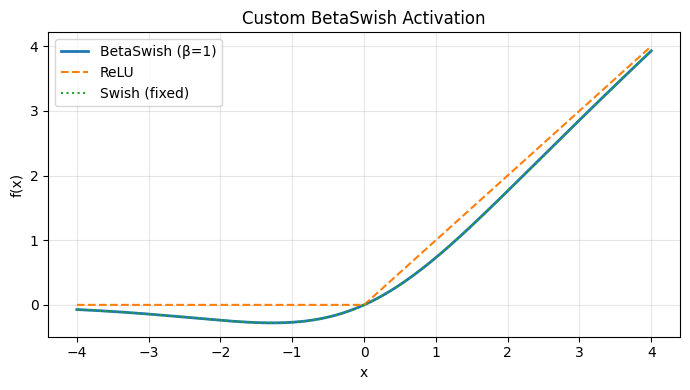

In [4]:
class BetaSwish(tf.keras.layers.Layer):
    """
    Parameterised Swish: f(x) = x * sigmoid(beta * x)
    beta is a trainable scalar that adapts during training.
    When beta=1 this reduces to standard Swish.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.beta = self.add_weight(name="beta", shape=(), initializer="ones",
                                    trainable=True)
        super().build(input_shape)

    def call(self, x):
        return x * tf.sigmoid(self.beta * x)

    def get_config(self):
        return super().get_config()

# Visualise activation curve
x_vis = np.linspace(-4, 4, 200).astype("float32")
layer = BetaSwish()
y_vis = layer(x_vis).numpy()

plt.figure(figsize=(7,4))
plt.plot(x_vis, y_vis,             label="BetaSwish (β=1)", linewidth=2)
plt.plot(x_vis, np.where(x_vis>0, x_vis, 0), label="ReLU", linestyle="--")
plt.plot(x_vis, x_vis*tf.sigmoid(x_vis).numpy(), label="Swish (fixed)", linestyle=":")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.title("Custom BetaSwish Activation")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


---
## 3 · Custom Weight Initializer — Scaled Orthogonal

In [5]:
class ScaledOrthogonalInitializer(tf.keras.initializers.Initializer):
    """
    Orthogonal init scaled by a user-defined gain.
    Orthogonal weights preserve gradient norms in very deep networks.
    """
    def __init__(self, gain=1.0):
        self.gain = gain

    def __call__(self, shape, dtype=None):
        flat_shape = (shape[0], int(np.prod(shape[1:])))
        a = tf.random.normal(flat_shape, dtype=dtype or tf.float32)
        s, u, v = tf.linalg.svd(a, full_matrices=False)
        q = u if u.shape == flat_shape else v
        q = tf.reshape(q, shape)
        return self.gain * q

    def get_config(self):
        return {"gain": self.gain}

# Quick test: verify orthogonality
init = ScaledOrthogonalInitializer(gain=1.2)
W = init((64, 64)).numpy()
WWT = W @ W.T
print(f"Off-diagonal mean: {np.abs(WWT - np.eye(64)).mean():.6f}  (should be near 0)")


Off-diagonal mean: 0.006875  (should be near 0)


---
## 4 · Custom Regularizer — Log Barrier

In [6]:
class LogBarrierRegularizer(tf.keras.regularizers.Regularizer):
    """
    Log-barrier: penalises weights close to zero to encourage non-sparse solutions.
    penalty = -strength * sum(log(|w| + eps))
    Useful in certain physics-informed or positive-weight architectures.
    """
    def __init__(self, strength=1e-4, eps=1e-6):
        self.strength = strength
        self.eps      = eps

    def __call__(self, weights):
        return -self.strength * tf.reduce_sum(tf.math.log(tf.abs(weights) + self.eps))

    def get_config(self):
        return {"strength": self.strength, "eps": self.eps}


---
## 5 · Custom Kernel Constraint — UnitNorm per Neuron

In [7]:
class MaxWeightNorm(tf.keras.constraints.Constraint):
    """
    Clips each neuron's incoming weight vector to have L2 norm <= max_norm.
    Prevents any single neuron from dominating by growing unboundedly.
    """
    def __init__(self, max_norm=2.0, axis=0):
        self.max_norm = max_norm
        self.axis     = axis

    def __call__(self, weights):
        norms = tf.norm(weights, axis=self.axis, keepdims=True)
        desired = tf.minimum(norms, self.max_norm)
        return weights * (desired / (norms + 1e-8))

    def get_config(self):
        return {"max_norm": self.max_norm, "axis": self.axis}


---
## 6 · Custom Loss — Label-Smoothed Categorical Cross-Entropy

In [8]:
class LabelSmoothingLoss(tf.keras.losses.Loss):
    """
    Label smoothing prevents overconfident predictions by mixing
    the one-hot target with a uniform distribution.
    y_smooth = (1 - eps)*y_onehot + eps/num_classes
    """
    def __init__(self, num_classes=10, epsilon=0.1, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.epsilon     = epsilon

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_onehot = tf.one_hot(y_true, self.num_classes)          # (B, C)
        y_smooth = (1.0 - self.epsilon) * y_onehot +                    self.epsilon / self.num_classes                # smooth
        log_probs = tf.math.log(tf.clip_by_value(y_pred, 1e-7, 1.0))
        return -tf.reduce_mean(tf.reduce_sum(y_smooth * log_probs, axis=-1))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_classes": self.num_classes, "epsilon": self.epsilon})
        return cfg

# Quick sanity check
y_true = tf.constant([3, 7])
y_pred = tf.constant([[0.1]*9+[0.1], [0.1]*7+[0.9,0.0,0.0]], dtype=tf.float32)
ls_loss = LabelSmoothingLoss(epsilon=0.1)
print("Label-smooth loss:", ls_loss(y_true, y_pred).numpy())


Label-smooth loss: 1.4410031


---
## 7 · Custom Metric — Top-3 Accuracy

In [9]:
class TopKAccuracy(tf.keras.metrics.Metric):
    """Reports fraction of samples where correct label is in top-k predictions."""
    def __init__(self, k=3, name="top3_acc", **kwargs):
        super().__init__(name=name, **kwargs)
        self.k       = k
        self.correct = self.add_weight(name="correct", initializer="zeros")
        self.total   = self.add_weight(name="total",   initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        top_k_preds = tf.math.top_k(y_pred, k=self.k).indices   # (B, k)
        y_true_expanded = tf.cast(tf.expand_dims(y_true, 1), tf.int32)  # (B,1)
        match = tf.reduce_any(tf.equal(top_k_preds, y_true_expanded), axis=1)
        self.correct.assign_add(tf.reduce_sum(tf.cast(match, tf.float32)))
        self.total.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.correct / self.total

    def reset_state(self):
        self.correct.assign(0.); self.total.assign(0.)


---
## 8 · Custom Layer — Squeeze-and-Excitation (SE) Block

In [10]:
class SqueezeExcitation(tf.keras.layers.Layer):
    """
    Channel attention: learn which feature maps to emphasise.
    SE(x) = x * sigmoid(W2 * ReLU(W1 * GlobalAvgPool(x)))
    """
    def __init__(self, ratio=4, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap  = tf.keras.layers.GlobalAveragePooling2D()
        self.fc1  = tf.keras.layers.Dense(channels // self.ratio, activation="relu")
        self.fc2  = tf.keras.layers.Dense(channels, activation="sigmoid")
        self.reshape = tf.keras.layers.Reshape((1, 1, channels))

    def call(self, x):
        scale = self.gap(x)            # (B, C)
        scale = self.fc1(scale)        # (B, C//ratio)
        scale = self.fc2(scale)        # (B, C)
        scale = self.reshape(scale)    # (B, 1, 1, C)
        return x * scale               # channel-wise multiplication

    def get_config(self):
        cfg = super().get_config(); cfg.update({"ratio": self.ratio}); return cfg

# Test SE block
dummy_feat = tf.random.normal((4, 7, 7, 64))
se = SqueezeExcitation(ratio=4)
out = se(dummy_feat)
print("SE output shape:", out.shape)   # should be (4,7,7,64)


SE output shape: (4, 7, 7, 64)


---
## 9 · Custom Model — ResNet-style Residual Block

In [11]:
class ResidualBlock(tf.keras.layers.Layer):
    """Mini residual block with optional projection shortcut."""
    def __init__(self, filters, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = layers.Conv2D(filters, 3, strides=strides, padding="same")
        self.bn1   = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, padding="same")
        self.bn2   = layers.BatchNormalization()
        self.se    = SqueezeExcitation(ratio=4)
        self.project = None
        self._strides = strides; self._filters = filters

    def build(self, input_shape):
        # If shapes don't match, add 1x1 projection
        if input_shape[-1] != self._filters or self._strides != 1:
            self.project = layers.Conv2D(self._filters, 1, strides=self._strides)
        super().build(input_shape)

    def call(self, x, training=False):
        residual = x if self.project is None else self.project(x)
        out = tf.nn.relu(self.bn1(self.conv1(x), training=training))
        out = self.bn2(self.conv2(out), training=training)
        out = self.se(out)
        return tf.nn.relu(out + residual)

class MiniResNet(tf.keras.Model):
    """A small but complete residual network."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem  = layers.Conv2D(32, 3, padding="same")
        self.bn0   = layers.BatchNormalization()
        self.res1  = ResidualBlock(32)
        self.res2  = ResidualBlock(64, strides=2)
        self.res3  = ResidualBlock(64)
        self.gap   = layers.GlobalAveragePooling2D()
        self.drop  = layers.Dropout(0.3)
        self.head  = layers.Dense(num_classes, activation="softmax")

    def call(self, x, training=False):
        x = tf.nn.relu(self.bn0(self.stem(x), training=training))
        x = self.res1(x, training=training)
        x = self.res2(x, training=training)
        x = self.res3(x, training=training)
        x = self.drop(self.gap(x), training=training)
        return self.head(x)

mini_res = MiniResNet()
mini_res.compile(
    optimizer="adam",
    loss=LabelSmoothingLoss(epsilon=0.1),
    metrics=["accuracy", TopKAccuracy(k=3)]
)

hist_res = mini_res.fit(x_tr, y_tr, epochs=12, batch_size=64,
                        validation_data=(x_val, y_val), verbose=1)


Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.6001 - loss: 1.3909 - top3_acc: 0.8763 - val_accuracy: 0.0975 - val_loss: 2.9563 - val_top3_acc: 0.3080
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7595 - loss: 1.0569 - top3_acc: 0.9604 - val_accuracy: 0.0990 - val_loss: 2.9191 - val_top3_acc: 0.3000
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8041 - loss: 0.9740 - top3_acc: 0.9719 - val_accuracy: 0.1995 - val_loss: 3.1258 - val_top3_acc: 0.4035
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8340 - loss: 0.9127 - top3_acc: 0.9778 - val_accuracy: 0.2945 - val_loss: 2.3890 - val_top3_acc: 0.6630
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8516 - loss: 0.8786 - top3_acc: 0.9809 - val_accuracy: 0.6635 - val_loss: 1.3239 - val_top3_acc: 0.8895
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8656 - loss: 0.8526 - top3_acc: 0.9834 - val_accuracy: 0.7685 - val_loss: 1.0090 -

## 10 · A/B Comparison — Standard vs Custom Components

In [12]:
# Standard model
def build_standard():
    m = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=(28,28,1)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax"),
    ])
    m.compile("adam","sparse_categorical_crossentropy",metrics=["accuracy"])
    return m

std = build_standard()
hist_std = std.fit(x_tr, y_tr, epochs=12, batch_size=64,
                   validation_data=(x_val, y_val), verbose=0)

_, std_acc  = std.evaluate(x_test, y_test, verbose=0)
res_metrics = mini_res.evaluate(x_test, y_test, verbose=0)
res_acc     = res_metrics[1]

df = pd.DataFrame([
    {"Model": "Standard CNN",    "Test Acc": round(std_acc, 4),
     "Top-3 Acc": "N/A",         "Custom Components": "None"},
    {"Model": "MiniResNet + Custom Objects", "Test Acc": round(res_acc, 4),
     "Top-3 Acc": round(res_metrics[2], 4), "Custom Components":
     "BetaSwish, SE, LabelSmoothing, Top3Metric"},
])
print(df.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


                      Model  Test Acc Top-3 Acc                         Custom Components
               Standard CNN    0.8652       N/A                                      None
MiniResNet + Custom Objects    0.8212    0.9742 BetaSwish, SE, LabelSmoothing, Top3Metric


## 11 · Conclusion

| Custom Object | Purpose | Key Insight |
|---|---|---|
| **BetaSwish** | Learnable activation | β adapts per-network; often beats ReLU |
| **ScaledOrthogonal Init** | Weight init | Preserves gradient norms in deep nets |
| **LogBarrier Reg** | Regularisation | Encourages non-zero weights |
| **MaxWeightNorm** | Constraint | Caps neuron weight norms during training |
| **LabelSmoothing Loss** | Loss | Reduces overconfidence; improves calibration |
| **TopK Metric** | Metric | Useful when class ordering matters |
| **SE Block** | Layer | Channel attention; cheap and effective |
| **MiniResNet** | Model | Residual connections prevent degradation |

> Every custom object uses `get_config()` enabling full serialisation and `model.save()` support.
